In [1]:
# 1. INSTALLATIONS (Updated with explicit ragas version for stability)
!pip install langchain openai langchain_community GitPython chromadb tiktoken sentence-transformers "ragas>=0.2" datasets rapidfuzz
!pip install -U langchain-text-splitters langchain-openai
!pip install -U langchain-classic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 k

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from git import Repo
from google.colab import userdata, files
from datasets import Dataset

# LangChain & Ragas Imports
from langchain_community.document_loaders.generic import GenericLoader
from langchain_community.document_loaders.parsers import LanguageParser
from langchain_text_splitters import Language, RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from sentence_transformers import CrossEncoder

from ragas.testset import TestsetGenerator
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas import evaluate
from ragas.metrics import faithfulness, answer_correctness, context_precision

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipykernel_307/2656862867.py:20: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_correctness, context_precision
/tmp/ipykernel_307/2656862867.py:20: DeprecationWarning: Importing answer_correctness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections

Cloning repository...
Loaded 471 total files.
Generating 50-question test set (this may take a few minutes)...


/tmp/ipykernel_28972/1407389511.py:34: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  llm=LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini")),
/tmp/ipykernel_28972/1407389511.py:35: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  embedding_model=LangchainEmbeddingsWrapper(OpenAIEmbeddings())


Applying SummaryExtractor:   0%|          | 0/20 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/20 [00:00<?, ?it/s]

Applying EmbeddingExtractor:   0%|          | 0/20 [00:00<?, ?it/s]

...


--- Starting Experiment: Size_5000 ---


Evaluating:   0%|          | 0/144 [00:00<?, ?it/s]


--- Starting Experiment: Size_1000_RR ---


Evaluating:   0%|          | 0/144 [00:00<?, ?it/s]


--- FINAL COMPARISON ---
              faithfulness  answer_correctness  context_precision
Size_500          0.798024            0.668956           0.362903
Size_1000         0.819561            0.681739           0.455462
Size_3000         0.798304            0.703406           0.718142
Size_5000         0.749704            0.701750           0.847222
Size_1000_RR      0.811344            0.707790           0.494029


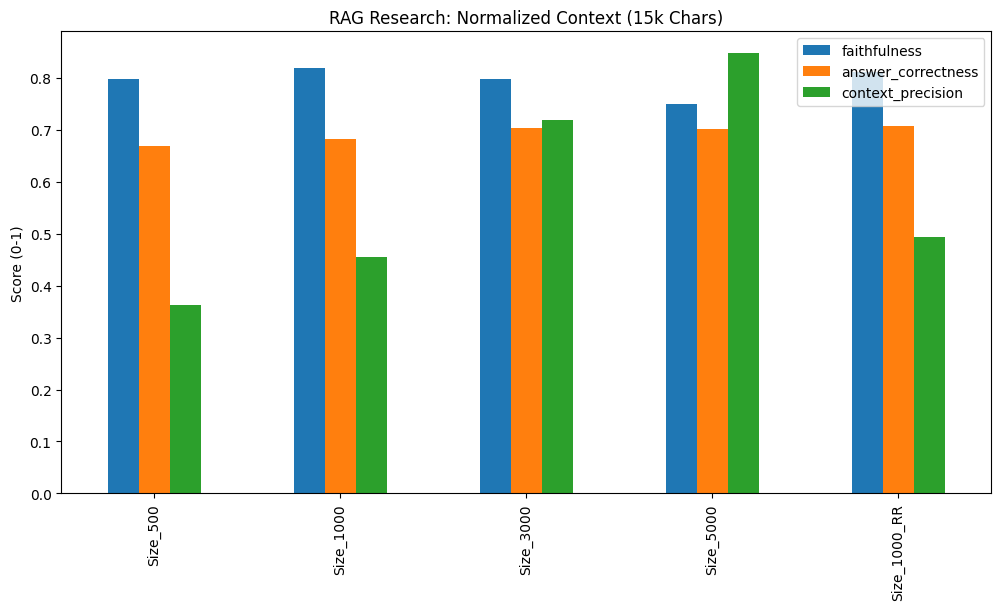

In [ ]:
# --- CONFIGURATION ---
TOTAL_CONTEXT_LIMIT = 15000  # Fair character budget for research
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# 1. SETUP REPO (Fresh Clone)
print("Cloning repository...")
!rm -rf local_copy_repo
Repo.clone_from("https://github.com/scikit-learn/scikit-learn", "local_copy_repo")

# 2. LOAD DOCUMENTS (Python-Aware)
loader = GenericLoader.from_filesystem(
    "local_copy_repo/examples",
    suffixes=[".py"],
    glob="**/*.py",
    parser=LanguageParser(language=Language.PYTHON)
)
documents = loader.load()
print(f"Loaded {len(documents)} total files.")

# 3. HELPER: DEDUPLICATION
def get_unique_docs(docs):
    seen = set()
    unique = []
    for d in docs:
        if d.page_content not in seen:
            unique.append(d)
            seen.add(d.page_content)
    return unique

# 4. GENERATE EVALUATION DATASET
print("Generating 50-question test set (this may take a few minutes)...")
docs_for_gen = documents[:20]
generator = TestsetGenerator(
    llm=LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini")),
    embedding_model=LangchainEmbeddingsWrapper(OpenAIEmbeddings())
)

try:
    testset = generator.generate_with_chunks(chunks=docs_for_gen, testset_size=50)
except:
    testset = generator.generate_with_chunks(chunks=docs_for_gen, test_size=50)

test_df = testset.to_pandas()
mapping = {'user_input': 'question', 'reference': 'ground_truth', 'reference_contexts': 'context'}
test_df = test_df.rename(columns={k: v for k, v in mapping.items() if k in test_df.columns})

# DOWNLOAD THE TEST SET IMMEDIATELY FOR SAFETY
test_df.to_csv("ragas_test_set.csv", index=False)
files.download("ragas_test_set.csv")

# 5. RERANK LOGIC
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

# 6. IMPROVED EVALUATION FUNCTION
def run_experiment(chunk_size, use_rerank=False):
    # DYNAMIC K: Standardizing the context volume across all tests
    target_k = max(1, TOTAL_CONTEXT_LIMIT // chunk_size)

    # Python-Safe Splitting
    text_splitter = RecursiveCharacterTextSplitter.from_language(
        language=Language.PYTHON,
        chunk_size=chunk_size,
        chunk_overlap=chunk_size // 10
    )
    chunks = text_splitter.split_documents(documents)

    # Vector Store
    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=OpenAIEmbeddings(),
        collection_name=f"coll_{chunk_size}_{use_rerank}"
    )

    fetch_k = target_k * 3 if use_rerank else target_k
    retriever = vectorstore.as_retriever(search_kwargs={"k": fetch_k})

    results = []
    for _, row in test_df.iterrows():
        query = row['question']
        raw_docs = retriever.invoke(query)
        unique_docs = get_unique_docs(raw_docs)

        if use_rerank:
            pairs = [[query, d.page_content] for d in unique_docs]
            scores = reranker.predict(pairs)
            scored = sorted(zip(unique_docs, scores), key=lambda x: x[1], reverse=True)
            final_docs = [d for d, s in scored[:target_k]]
        else:
            final_docs = unique_docs[:target_k]

        context_text = "\n\n".join([d.page_content for d in final_docs])

        # FIX 1: Answer concisely to keep evaluation payload small
        response = ChatOpenAI(model="gpt-4o-mini", temperature=0).invoke(
            f"Context: {context_text}\nQuestion: {query}\nAnswer concisely based only on the code."
        ).content

        results.append({
            "question": query, "answer": response,
            "contexts": [d.page_content for d in final_docs],
            "ground_truth": row['ground_truth']
        })

    # FIX 2: Increase max_tokens for the Evaluator to prevent JSON cutoff
    evaluator_llm = ChatOpenAI(model="gpt-4o-mini", max_tokens=3500)

    eval_ds = Dataset.from_list(results)
    score = evaluate(
        eval_ds,
        metrics=[faithfulness, answer_correctness, context_precision],
        llm=evaluator_llm,
        embeddings=OpenAIEmbeddings()
    )

    vectorstore.delete_collection()
    return score.to_pandas().mean(numeric_only=True)

# 7. RUN THE 5 RESEARCH CONFIGS
configs = [
    {"size": 500, "rerank": False},
    {"size": 1000, "rerank": False},
    {"size": 3000, "rerank": False},
    {"size": 5000, "rerank": False},
    {"size": 1000, "rerank": True}
]

final_comparison = {}
for cfg in configs:
    label = f"Size_{cfg['size']}{'_RR' if cfg['rerank'] else ''}"
    print(f"\n--- Starting Experiment: {label} ---")
    final_comparison[label] = run_experiment(cfg['size'], cfg['rerank'])

# 8. VISUALIZE
comparison_df = pd.DataFrame(final_comparison).T
print("\n--- FINAL COMPARISON ---")
print(comparison_df)
comparison_df.plot(kind="bar", figsize=(12, 6), title="RAG Research: Normalized Context (15k Chars)")
plt.ylabel("Score (0-1)")
plt.show()

In [ ]:
'''from google.colab import files

test_df.to_csv("ragas_test_set.csv", index=False)
files.download("ragas_test_set.csv")'''

In [ ]:
# 3000

In [3]:
# 2. CONFIGURATION
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
embeddings = OpenAIEmbeddings()
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# 3. SETUP REPO
if not os.path.exists("local_copy_repo"):
    print("Cloning repository...")
    Repo.clone_from("https://github.com/scikit-learn/scikit-learn", "local_copy_repo")

# 4. LOAD (Python-Aware Logic)
loader = GenericLoader.from_filesystem(
    "local_copy_repo/examples",
    suffixes=[".py"],
    glob="**/*.py",
    parser=LanguageParser(language=Language.PYTHON)
)
documents = loader.load()

# 5. SPLIT (The 3000-character Winner)
python_splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.PYTHON,
    chunk_size=3000,
    chunk_overlap=300
)
chunks = python_splitter.split_documents(documents)

# 6. STORE
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="sklearn_research_final"
)

# 7. RETRIEVER (k=5 for the 15k limit)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

# 8. THE ASK FUNCTION (Mirroring your Experiment logic)
def ask_sklearn(query):
    # Step A: Retrieve (Same as test)
    relevant_docs = retriever.invoke(query)

    # Step B: Build Context String (Same as test)
    context_text = "\n\n".join([d.page_content for d in relevant_docs])

    # Step C: Generate Answer (Same as test)
    prompt = f"Context: {context_text}\n\nQuestion: {query}\n\nAnswer concisely based only on the code."
    answer = llm.invoke(prompt).content

    print(f"\n{'='*40}")
    print(f"QUESTION: {query}")
    print(f"{'='*40}\n")
    print(answer)
    print(f"\n{'='*40}")

print(f"Ready! Built with {len(chunks)} chunks using the exact Research Script logic.")

Cloning repository...
Ready! Built with 914 chunks using the exact Research Script logic.


In [4]:
response = ask_sklearn("How do I use a Pipeline with a RandomForestClassifier?")
print(response)


QUESTION: How do I use a Pipeline with a RandomForestClassifier?

To use a `Pipeline` with a `RandomForestClassifier`, you can follow these steps:

1. Define the preprocessing steps using `ColumnTransformer` for numerical and categorical features.
2. Create a `Pipeline` that includes the preprocessing steps and the `RandomForestClassifier`.

Here’s a concise example based on the provided code:

```python
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define preprocessing for numerical and categorical features
numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("oneh

In [5]:
response = ask_sklearn("Code for RandomForestClassifier?")
print(response)


QUESTION: Code for RandomForestClassifier?

```python
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0, ccp_alpha=0).fit(X, y)
rf = RandomForestClassifier(random_state=0, ccp_alpha=0.05).fit(X, y)

pipe = Pipeline(
    steps=[("preprocessor", preprocessor), ("classifier", RandomForestClassifier())]
)

rfc = RandomForestClassifier(random_state=42)
```

None


In [6]:
response = ask_sklearn("Code for Random Forest")
print(response)


QUESTION: Code for Random Forest

```python
from sklearn.ensemble import RandomForestClassifier

# Create and fit the Random Forest model
rf = RandomForestClassifier(random_state=0).fit(X, y)

# Predict using the fitted model
predictions = rf.predict(X)
```

None
